# 09. Machine-learned potentials: from a toy MD to a foundation model

**Goal.** Generate a trajectory with a modern machine-learned interatomic potential and analyse it with
Sapphire exactly as before — the analysis pipeline does not care where the frames came from.

**You need.** `pip install -e ".[mlpot]"` for MACE (+ PyTorch, ~2 GB). Without it this notebook
falls back to ASE's EMT so it still runs (and in CI).

## 9.1 Why

Sapphire's original roadmap (2019–21) listed FLARE Gaussian-process force fields and TensorFlow.
Since then *foundation models* — equivariant neural-network potentials trained across the periodic
table on Materials-Project DFT — give near-DFT forces for metals **with no training step**.
MACE‑MP‑0 (Batatia et al. 2023) is the reference example; see `docs/ML_POTENTIALS.md`.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from Sapphire.Potentials.MLCalculator import calculator_or_emt
from Sapphire.Tutorials import data

calc, name = calculator_or_emt("mace-mp-0")          # MACE if installed, otherwise EMT
print("potential:", name)

potential: EMT (install the 'mlpot' extra for mace-mp-0)


## 9.2 A short Langevin run of a Pt icosahedron

`data.synthetic` builds an icosahedron, thermalises it and writes an xyz. Swap the calculator and the
rest of Sapphire is unchanged.

In [2]:
work = os.path.abspath("run_ml") + "/"; os.makedirs(work, exist_ok=True)
frames = data.synthetic(n_frames=20, element="Pt", noshells=3, temperature_K=800.0, seed=0, out=work + "movie.xyz", calculator=calc)
E = [a.get_potential_energy() if a.calc else np.nan for a in frames]
print(len(frames), "frames of", len(frames[0]), "atoms")

20 frames of 55 atoms


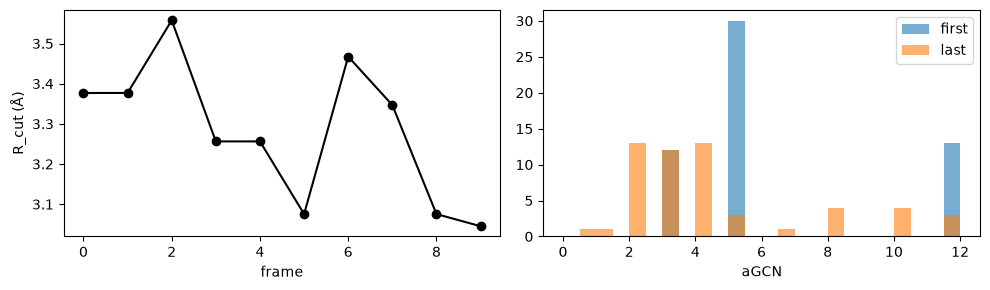

In [3]:
from Sapphire import Process
System = {"base_dir": work, "movie_file_name": "movie.xyz", "extend_xyz": None, "Homo": None, "Hetero": False,
          "Start": 0, "End": 20, "Step": 2, "Skip": 1, "UniformPDF": False, "Band": 0.05}
proc = Process.Process(System=System, Quantities={"Full": {"pdf": None, "adj": None, "nn": None, "agcn": None, "cna_sigs": None, "gyration": None}})
m = proc.reader().load_all()
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].plot(m["rcut"], "ko-"); ax[0].set_ylabel("R_cut (Å)"); ax[0].set_xlabel("frame")
ax[1].hist(m["agcn"][0], bins=24, range=(0, 12), alpha=.6, label="first"); ax[1].hist(m["agcn"][-1], bins=24, range=(0, 12), alpha=.6, label="last"); ax[1].legend(); ax[1].set_xlabel("aGCN")
plt.tight_layout(); plt.show()

## 9.3 Mass activity along the run

With Pt atoms the aGCN histogram feeds the ORR model of Tutorial 03 frame by frame.

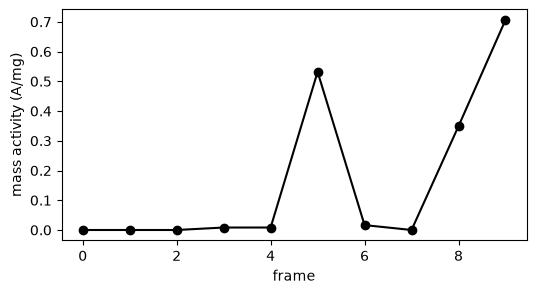

mean MA = 0.162 A/mg with EMT (install the 'mlpot' extra for mace-mp-0)


In [4]:
from Sapphire.Post_Process import Mass_Activity as MA
ma = MA.mass_activity_series(m["agcn"], frames[0].get_chemical_symbols())
plt.figure(figsize=(6, 3)); plt.plot(ma, "ko-"); plt.xlabel("frame"); plt.ylabel("mass activity (A/mg)"); plt.show()
print("mean MA = %.3f A/mg with %s" % (ma.mean(), name))

## 9.4 Going further

* `ml_calculator("mace-mpa-0")` — the newer MPA‑0 weights; `device="cuda"` on a GPU.
* Fine-tune MACE on a few hundred DFT frames of *your* alloy for quantitative energetics; the MACE
  documentation covers this in one script.
* Compare with the classical Gupta potential (`Sapphire.Potentials.Gupta`) on the same cluster.

Sapphire's role stays the same throughout: turn frames into structure descriptors and statistics.